# Comparing Neural-Network Representations with CKA

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/representation_similarity.ipynb)

Do two networks trained from different seeds learn the same features? Does a wider network learn different ones? Centred kernel alignment (CKA) answers this layer by layer (Kornblith et al., 2019): feed the same inputs through both networks, collect the activations of every layer, and compare the activation matrices with `kl.cka`. CKA compares *representations* (matrices whose rows are paired by input), not weights, so it works across widths, and it ignores the arbitrary rotation and scale a layer can have.

**What you'll learn:**

1. Layer-by-layer CKA heatmaps, for two seeds of one architecture and for a narrow against a wide network
2. Linear against RBF CKA, and the debiased (`estimator="unbiased"`) form
3. Which transforms CKA is invariant to, asserted on real activations, and why linear CKA is the RV coefficient
4. The bias of plain CKA at small $N$ and large width, and how the debiased estimator removes it
5. CKA over a large evaluation set, batch by batch, with `CKAAccumulator`

## Background

For column-centred activation matrices $X \in \mathbb R^{N\times D_x}$ and $Y \in \mathbb R^{N\times D_y}$ (rows paired by input), linear CKA is

$$\mathrm{CKA}(X, Y) = \frac{\|Y^\top X\|_F^2}{\|X^\top X\|_F\,\|Y^\top Y\|_F},$$

the RV coefficient. In general, CKA is $\mathrm{HSIC}(K, L)/\sqrt{\mathrm{HSIC}(K, K)\,\mathrm{HSIC}(L, L)}$ for Gram matrices $K$ on $X$ and $L$ on $Y$; a linear kernel gives the formula above and an RBF kernel a nonlinear variant. kernellib's `estimator="unbiased"` replaces each HSIC with the unbiased estimator of Song et al. (2012), computed as an inner product of U-centred Gram matrices (Székely & Rizzo, 2014), which is the same estimator in a form that does not cancel catastrophically in float32.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    pipekit = "git+https://github.com/jejjohnson/pipekit.git@pipekit-train-v0.0.2"
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib @ git+https://github.com/jejjohnson/kernellib@main",
            "optax",
            f"pipekit @ {pipekit}#subdirectory=packages/pipekit",
            f"pipekit-train[equinox] @ {pipekit}#subdirectory=packages/pipekit-train",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import logging
import time

import einx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from pipekit_train import TrainingDataset, TrainingLoop
from pipekit_train.adapters.equinox import EquinoxModelOp

import kernellib as kl


jax.config.update("jax_enable_x64", True)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
notebook_start = time.perf_counter()

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark", "-v -m -p jax,equinox,optax,pipekit_train,matplotlib,kernellib"
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.17.1

jax          : 0.11.2
equinox      : 0.13.8
optax        : 0.2.8
pipekit_train: 0.0.2
matplotlib   : 3.11.2
kernellib    : 0.0.16

Compiler    : Clang 21.1.4 
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## A two-arm spiral

Two interleaved spiral arms in 2D, one class each, with a little noise: 2,000 points to train on and 1,000 held out, from separate keys.

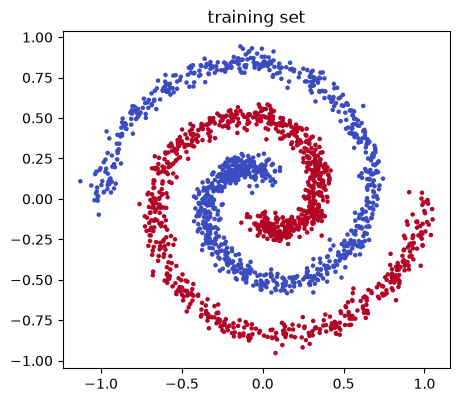

In [4]:
def spiral(n, key, noise=0.04):
    k_class, k_t, k_noise = jax.random.split(key, 3)
    label = jax.random.bernoulli(k_class, 0.5, (n,)).astype(jnp.int32)
    t = jax.random.uniform(k_t, (n,), minval=0.15, maxval=1.0)
    angle = 3.0 * jnp.pi * t + jnp.pi * label
    circle = jnp.stack([jnp.cos(angle), jnp.sin(angle)], axis=-1)
    X = einx.multiply("n, n d -> n d", t, circle)
    return X + noise * jax.random.normal(k_noise, (n, 2)), label


X_train, c_train = spiral(2000, jax.random.key(0))
X_eval, c_eval = spiral(1000, jax.random.key(1))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_train[:, 0], X_train[:, 1], c=c_train, cmap="coolwarm", s=5)
ax.set_aspect("equal")
ax.set_title("training set")
plt.show()

## Three MLPs, trained with pipekit-train

Two ReLU MLPs with four hidden layers of width 64 (seeds 0 and 1), and one with width 256 (seed 2). Training uses [pipekit-train](https://github.com/jejjohnson/pipekit)'s `TrainingLoop` with its Equinox backend: the objective is a `TrainTask` (`loss_fn(model, batch, key) -> (loss, metrics)`), and a small indexable `TrainingDataset` lets the backend shuffle the batches.

In [5]:
class ArrayDataset(TrainingDataset):
    """In-memory (input, target) pairs; indexable, so batches are shuffled."""

    def __init__(self, inputs, targets, name):
        super().__init__()
        self.inputs, self.targets = np.asarray(inputs), np.asarray(targets)
        self.name = name

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, i):
        return self.inputs[i], self.targets[i]

    def __iter__(self):
        for i in range(len(self)):
            yield self[i]

    def get_config(self):
        return {"name": self.name, "n": len(self)}


class CrossEntropy:
    """A pipekit TrainTask: softmax cross-entropy, with accuracy as a metric."""

    def loss_fn(self, model, batch, key):
        x, label = batch
        logits = jax.vmap(model)(x)
        loss = jnp.mean(optax.softmax_cross_entropy_with_integer_labels(logits, label))
        accuracy = jnp.mean(einx.argmax("n [c] -> n", logits) == label)
        return loss, {"loss": loss, "accuracy": accuracy}


train_set = ArrayDataset(X_train, c_train, "spiral-2000")
specs = {"narrow, seed 0": (64, 0), "narrow, seed 1": (64, 1), "wide, seed 2": (256, 2)}

t0 = time.perf_counter()
nets = {}
for name, (width, seed) in specs.items():
    mlp = eqx.nn.MLP(2, 2, width, 4, activation=jax.nn.relu, key=jax.random.key(seed))
    loop = TrainingLoop(
        model_op=EquinoxModelOp(mlp),
        dataset=train_set,
        task=CrossEntropy(),
        optimizer_config={"name": "adam", "learning_rate": 5e-3},
        max_steps=400,
        batch_size=128,
        seed=seed,
        backend="equinox",
    )
    trained, artifact = loop.run()
    nets[name] = trained.module
    logits = jax.vmap(trained.module)(X_eval)
    held_out = float(jnp.mean(einx.argmax("n [c] -> n", logits) == c_eval))
    print(
        f"{name}: held-out accuracy {held_out:.4f} "
        f"({artifact.backend_info['total_seconds']:.1f} s)"
    )
print(f"training: {time.perf_counter() - t0:.1f} s")

narrow, seed 0: held-out accuracy 1.0000 (22.1 s)


narrow, seed 1: held-out accuracy 0.9930 (24.1 s)


wide, seed 2: held-out accuracy 0.9960 (21.6 s)
training: 74.0 s


## Activations of every layer

`eqx.nn.MLP` stores its linear layers in `.layers`. We record the post-activation output of each hidden layer and the final logits, on the 1,000 held-out points.

In [6]:
def representations(mlp, X):
    """Post-ReLU activations of every hidden layer, then the logits."""

    def single(x):
        out = []
        for layer in mlp.layers[:-1]:
            x = mlp.activation(layer(x))
            out.append(x)
        out.append(mlp.layers[-1](x))
        return out

    return jax.vmap(single)(X)


layer_names = ["h1", "h2", "h3", "h4", "logits"]
acts = {name: representations(mlp, X_eval) for name, mlp in nets.items()}
for name, layers in acts.items():
    print(name, [tuple(a.shape) for a in layers])

narrow, seed 0 [(1000, 64), (1000, 64), (1000, 64), (1000, 64), (1000, 2)]
narrow, seed 1 [(1000, 64), (1000, 64), (1000, 64), (1000, 64), (1000, 2)]
wide, seed 2 [(1000, 256), (1000, 256), (1000, 256), (1000, 256), (1000, 2)]


## Layer × layer heatmaps

Three versions of CKA for every pair of layers: linear, RBF (each representation with its own median-heuristic lengthscale, as in issue #89's recipe) and linear with the unbiased estimator.

In [7]:
lin = kl.Linear()


def rbf(Z):
    return kl.RBF(lengthscale=kl.estimate_lengthscale(Z))


def cka_matrix(A_layers, B_layers, kind):
    def one(A, B):
        if kind == "linear":
            return kl.cka(lin, lin, A, B)
        if kind == "rbf":
            return kl.cka(rbf(A), rbf(B), A, B)
        return kl.cka(lin, lin, A, B, estimator="unbiased")

    return np.array([[float(one(A, B)) for B in B_layers] for A in A_layers])


t0 = time.perf_counter()
pairs = {
    "two seeds": ("narrow, seed 0", "narrow, seed 1"),
    "narrow vs wide": ("narrow, seed 0", "wide, seed 2"),
}
heat = {
    (pair, kind): cka_matrix(acts[a], acts[b], kind)
    for pair, (a, b) in pairs.items()
    for kind in ("linear", "rbf", "unbiased")
}
print(f"{len(heat)} heatmaps in {time.perf_counter() - t0:.1f} s")
for pair in pairs:
    print(f"\n{pair}, linear CKA (rows: first network, columns: second)")
    print("        " + "".join(f"{n:>8}" for n in layer_names))
    for name, row in zip(layer_names, heat[pair, "linear"], strict=True):
        print(f"{name:>8}" + "".join(f"{v:8.3f}" for v in row))

6 heatmaps in 101.6 s

two seeds, linear CKA (rows: first network, columns: second)
              h1      h2      h3      h4  logits
      h1   0.995   0.857   0.389   0.272   0.262
      h2   0.805   0.920   0.522   0.364   0.336
      h3   0.359   0.553   0.682   0.719   0.761
      h4   0.283   0.434   0.653   0.753   0.822
  logits   0.272   0.380   0.578   0.715   0.834

narrow vs wide, linear CKA (rows: first network, columns: second)
              h1      h2      h3      h4  logits
      h1   0.992   0.721   0.444   0.350   0.387
      h2   0.828   0.771   0.557   0.431   0.409
      h3   0.381   0.515   0.576   0.585   0.654
      h4   0.306   0.424   0.521   0.581   0.699
  logits   0.298   0.367   0.450   0.533   0.703


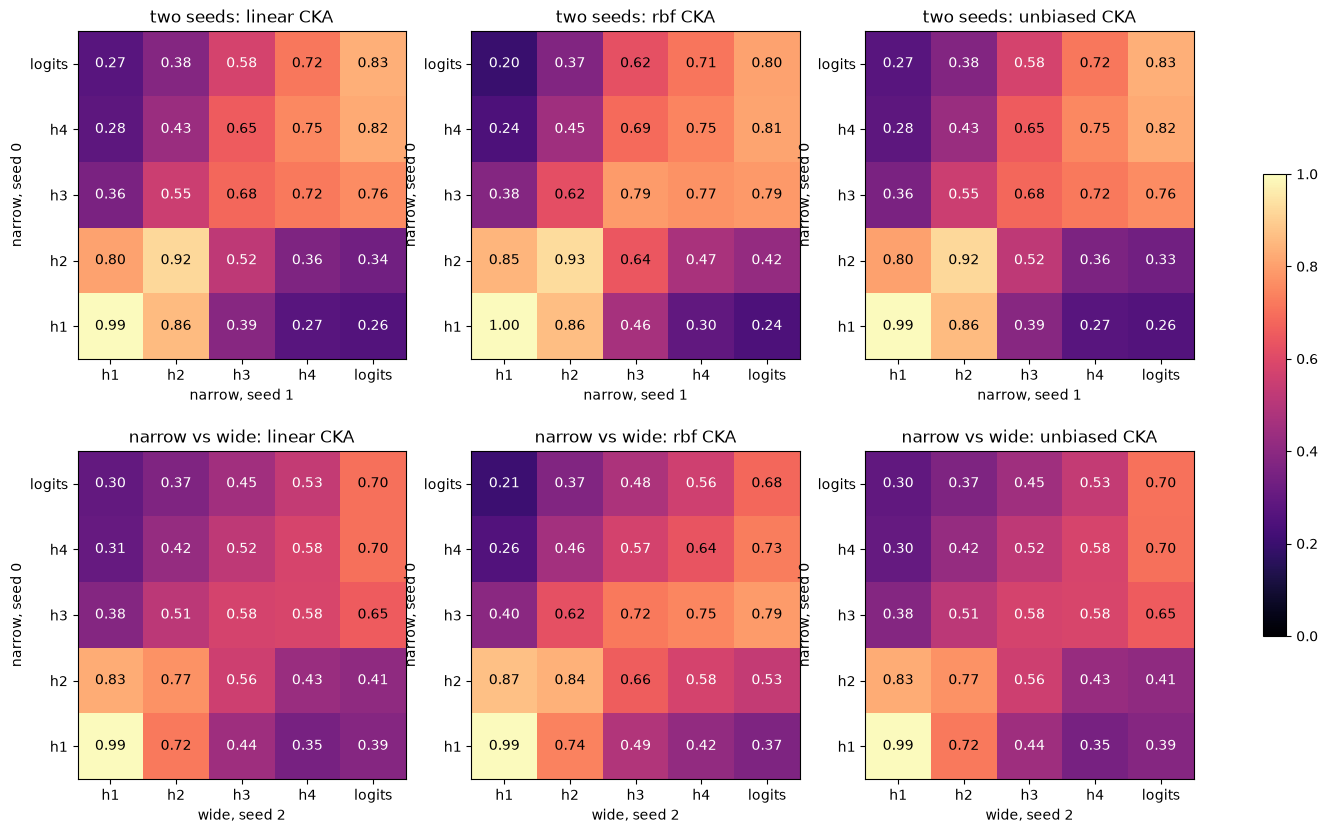

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for r, (pair, (a, b)) in enumerate(pairs.items()):
    for c, kind in enumerate(("linear", "rbf", "unbiased")):
        ax = axes[r, c]
        image = ax.imshow(
            heat[pair, kind], vmin=0, vmax=1, cmap="magma", origin="lower"
        )
        for i in range(len(layer_names)):
            for j in range(len(layer_names)):
                value = heat[pair, kind][i, j]
                colour = "k" if value > 0.6 else "w"
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=colour)
        ax.set_xticks(range(len(layer_names)), layer_names)
        ax.set_yticks(range(len(layer_names)), layer_names)
        ax.set_xlabel(b)
        ax.set_ylabel(a)
        ax.set_title(f"{pair}: {kind} CKA")
fig.colorbar(image, ax=axes, shrink=0.6)
plt.show()

**Two seeds, same architecture.** The first hidden layers are almost identical (linear CKA 0.995) and the second nearly so (0.920). The diagonal then dips at the third and fourth layers (0.682 and 0.753) and recovers at the logits (0.834), which both networks must align with the two classes. The deep hidden layers are where the seeds differ most, and they do not line up one to one: the seed-0 network's third layer is closer to the seed-1 network's logits (0.761) than to its third layer. The matrix is not symmetric, since rows and columns are different networks.

**Narrow against wide.** The first layers agree just as well (0.992), but every later diagonal entry is lower than for two seeds (0.771, 0.576, 0.581, 0.703): changing the width changes the intermediate features more than changing the seed. The RBF heatmaps show the same pattern with somewhat higher values in the middle (0.79 for the two seeds' third layers, against 0.68 linear), and the unbiased heatmaps are within 0.002 of the linear ones. The next section quantifies how closely they agree.

## Linear against RBF CKA

Kornblith et al. found that linear and RBF CKA rank layer pairs similarly. Each point below is one layer pair from the two heatmap rows above; the Spearman rank correlation is computed from the ranks with `jnp.corrcoef`.

Spearman(linear, RBF) = 0.968
Spearman(linear, unbiased) = 1.000
max |linear - unbiased linear| = 0.0020


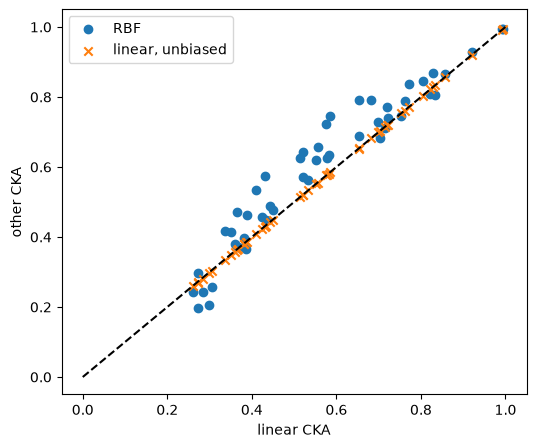

In [9]:
linear_values = np.concatenate(
    [einx.id("a b -> (a b)", heat[p, "linear"]) for p in pairs]
)
rbf_values = np.concatenate([einx.id("a b -> (a b)", heat[p, "rbf"]) for p in pairs])
unbiased_values = np.concatenate(
    [einx.id("a b -> (a b)", heat[p, "unbiased"]) for p in pairs]
)


def spearman(a, b):
    rank_a, rank_b = np.argsort(np.argsort(a)), np.argsort(np.argsort(b))
    return float(jnp.corrcoef(rank_a, rank_b)[0, 1])


print(f"Spearman(linear, RBF) = {spearman(linear_values, rbf_values):.3f}")
print(f"Spearman(linear, unbiased) = {spearman(linear_values, unbiased_values):.3f}")
gap = float(np.max(np.abs(linear_values - unbiased_values)))
print(f"max |linear - unbiased linear| = {gap:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(linear_values, rbf_values, label="RBF")
ax.scatter(linear_values, unbiased_values, marker="x", label="linear, unbiased")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("linear CKA")
ax.set_ylabel("other CKA")
ax.legend()
plt.show()

Over the 50 layer pairs, the Spearman correlation between linear and RBF CKA is 0.968: as Kornblith et al. report, the two kernels rank pairs almost identically. The unbiased estimator ranks them exactly the same (1.000) and differs from the biased value by at most 0.0020. With $N = 1000$ held-out points and at most 256 features per layer, the bias is small; the next sections show when it is not.

## Invariances

CKA is invariant to an orthogonal transform $Q$ and to isotropic scaling $c$ of either representation: $\mathrm{CKA}(XQ, Y) = \mathrm{CKA}(cX, Y) = \mathrm{CKA}(X, Y)$. Both hold for the linear and the RBF kernel (RBF distances are unchanged by $Q$, and the median-heuristic lengthscale scales with $c$). It is **not** invariant to an arbitrary invertible linear map $A$. CCA-style measures are, which makes them blind to how a layer stretches its features; we take $A$ to be a ridge-whitening map, $(\Sigma_X + \epsilon I)^{-1/2}$ with $\epsilon$ at $10^{-3}$ of the mean variance, which leaves a CCA-style comparison unchanged but gives every direction equal weight. Below, $X$ is the second hidden layer of the seed-0 network and $Y$ the same layer of the seed-1 network.

In [10]:
X_rep, Y_rep = acts["narrow, seed 0"][1], acts["narrow, seed 1"][1]
d = X_rep.shape[1]
Q, _ = jnp.linalg.qr(jax.random.normal(jax.random.key(10), (d, d)))
# An invertible map: (ridge-)whitening, the transform CCA-style measures ignore.
Xc = einx.subtract("n d, d -> n d", X_rep, einx.mean("n d -> d", X_rep))
cov = einx.dot("n i, n j -> i j", Xc, Xc) / len(Xc)
evals, evecs = jnp.linalg.eigh(cov + 1e-3 * jnp.trace(cov) / d * jnp.eye(d))
scaled = einx.multiply("i k, k -> i k", evecs, 1.0 / jnp.sqrt(evals))
A = einx.dot("i k, j k -> i j", scaled, evecs)
transforms = {
    "X": X_rep,
    "X Q (orthogonal)": einx.dot("n i, i j -> n j", X_rep, Q),
    "3.7 X (scaling)": 3.7 * X_rep,
    "X A (whitening)": einx.dot("n i, i j -> n j", X_rep, A),
}
base = {"linear": kl.cka(lin, lin, X_rep, Y_rep)}
base["rbf"] = kl.cka(rbf(X_rep), rbf(Y_rep), X_rep, Y_rep)
print(f"condition number of A: {float(jnp.linalg.cond(A)):.1f}")
print(f"{'':>18}  linear CKA  RBF CKA")
for name, Xt in transforms.items():
    values = (kl.cka(lin, lin, Xt, Y_rep), kl.cka(rbf(Xt), rbf(Y_rep), Xt, Y_rep))
    print(f"{name:>18}  {float(values[0]):10.6f}  {float(values[1]):7.6f}")

for name in ("X Q (orthogonal)", "3.7 X (scaling)"):
    Xt = transforms[name]
    assert jnp.allclose(kl.cka(lin, lin, Xt, Y_rep), base["linear"], rtol=1e-8)
    assert jnp.allclose(kl.cka(rbf(Xt), rbf(Y_rep), Xt, Y_rep), base["rbf"], rtol=1e-6)
XA = transforms["X A (whitening)"]
assert not jnp.allclose(kl.cka(lin, lin, XA, Y_rep), base["linear"], rtol=1e-2)
print("invariance asserts passed")

condition number of A: 176.1
                    linear CKA  RBF CKA


                 X    0.919679  0.929371


  X Q (orthogonal)    0.919679  0.929371


   3.7 X (scaling)    0.919679  0.929371


   X A (whitening)    0.341561  0.474737


invariance asserts passed


The orthogonal transform and the scaling leave both CKAs unchanged to six decimals (0.919679 linear, 0.929371 RBF), and the asserts pass. Whitening drops the linear CKA to 0.341561 and the RBF CKA to 0.474737: the two layers share their dominant directions, and whitening hands equal weight to the many small, noisier ones. That is the information a measure invariant to every invertible map throws away.

**Linear CKA is the RV coefficient.** Computed from the cross-covariance matrices with einx contractions, it matches `kl.cka` with `Linear` kernels to machine precision. The [Similarity measures](./similarity_measures.ipynb) notebook builds this connection up from Pearson's correlation.

In [11]:
def rv_coefficient(X, Y):
    Xc = einx.subtract("n d, d -> n d", X, einx.mean("n d -> d", X))
    Yc = einx.subtract("n d, d -> n d", Y, einx.mean("n d -> d", Y))
    xy = jnp.sum(einx.dot("n i, n j -> i j", Xc, Yc) ** 2)
    xx = jnp.sum(einx.dot("n i, n j -> i j", Xc, Xc) ** 2)
    yy = jnp.sum(einx.dot("n i, n j -> i j", Yc, Yc) ** 2)
    return xy / jnp.sqrt(xx * yy)


rv = rv_coefficient(X_rep, Y_rep)
print(f"RV = {float(rv):.12f}, linear CKA = {float(base['linear']):.12f}")
assert jnp.allclose(rv, base["linear"], rtol=1e-10)

RV = 0.919679314555, linear CKA = 0.919679314555


## Bias at small $N$

Plain (biased) CKA between two **independent** random matrices is far from 0 when the width $D$ is large compared with $N$: each Gram matrix is dominated by its diagonal, so the two look alike. The debiased estimator fixes this. Here $D = 512$ for both matrices, $N$ runs from 8 to 2,048, and each point is the mean of 5 draws.

bias sweep: 31.5 s
     N  biased  unbiased
     8   0.985   -0.0405
    16   0.973   +0.0354
    32   0.941   -0.0255
    64   0.889   +0.0070
   128   0.800   -0.0023
   256   0.668   +0.0023
   512   0.501   +0.0006
  1024   0.333   +0.0000
  2048   0.200   +0.0001


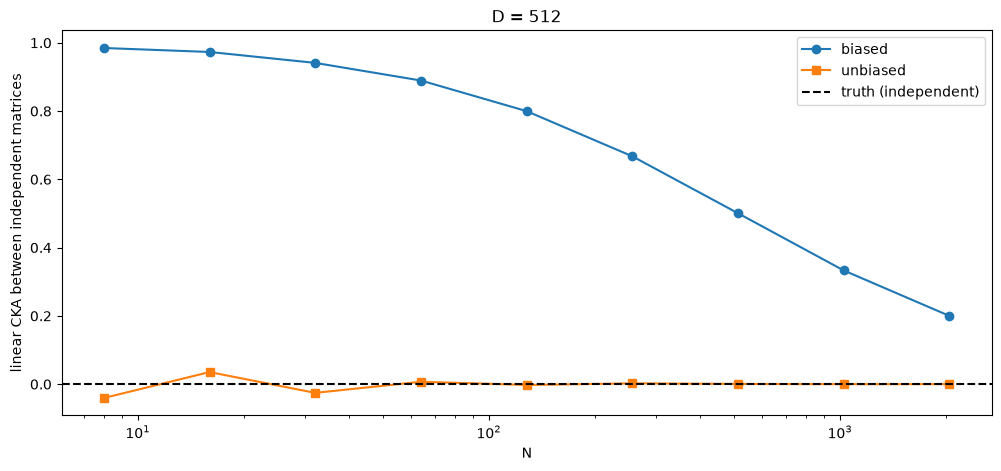

In [12]:
t0 = time.perf_counter()
sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
D = 512
bias = {"biased": [], "unbiased": []}
for n in sizes:
    for estimator in bias:
        draws = []
        for rep in range(5):
            k_a, k_b = jax.random.split(jax.random.key(100 * n + rep))
            A_rand = jax.random.normal(k_a, (n, D))
            B_rand = jax.random.normal(k_b, (n, D))
            draws.append(float(kl.cka(lin, lin, A_rand, B_rand, estimator=estimator)))
        bias[estimator].append(np.mean(draws))
print(f"bias sweep: {time.perf_counter() - t0:.1f} s")
print("     N  biased  unbiased")
for n, b, u in zip(sizes, bias["biased"], bias["unbiased"], strict=True):
    print(f"{n:6d}  {b:6.3f}  {u:+8.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogx(sizes, bias["biased"], "o-", label="biased")
ax.semilogx(sizes, bias["unbiased"], "s-", label="unbiased")
ax.axhline(0.0, color="k", ls="--", label="truth (independent)")
ax.set_xlabel("N")
ax.set_ylabel("linear CKA between independent matrices")
ax.set_title(f"D = {D}")
ax.legend()
plt.show()

Biased CKA between independent matrices is 0.985 at $N = 8$ and still 0.200 at $N = 2048$. It tracks $D/(N + D)$ closely (0.5 at $N = D = 512$, 0.333 at $N = 1024$): with $D \gg N$ every Gram matrix is dominated by its diagonal, so any two of them look alike. The unbiased estimator is centred on 0 at every $N$. It is noisy when $N$ is tiny ($-0.0405$ and $+0.0354$ for $N \le 16$) and within $\pm 0.0023$ from $N = 128$. Comparing wide layers on a few hundred inputs, as is common, calls for `estimator="unbiased"`.

## CKA over a large evaluation set: `CKAAccumulator`

CKA on $N$ points needs $N \times N$ Gram matrices. `CKAAccumulator` sums the unbiased HSIC terms batch by batch (Nguyen, Raghu & Kornblith, 2021), in $O(B^2)$ memory, and because every term is unbiased the result does not depend on the batch size. The batches must be random draws: here the evaluation set is i.i.d., so consecutive slices are. We compare the second hidden layers of the two seed networks on 4,000 fresh points, against the full-data unbiased CKA.

In [13]:
X_big, _ = spiral(4000, jax.random.key(2))
big_a = representations(nets["narrow, seed 0"], X_big)[1]
big_b = representations(nets["narrow, seed 1"], X_big)[1]

t0 = time.perf_counter()
full = float(kl.cka(lin, lin, big_a, big_b, estimator="unbiased"))
full_seconds = time.perf_counter() - t0
print(f"full-data unbiased CKA (N = 4000): {full:.4f} ({full_seconds:.1f} s)")

acc = kl.CKAAccumulator(lin, lin)
for start in range(0, len(X_big), 200):
    acc = acc.update(big_a[start : start + 200], big_b[start : start + 200])
print(
    f"mini-batch CKA, batch 200: {float(acc.result()):.4f} "
    f"({int(acc.n_batches)} batches)"
)

full-data unbiased CKA (N = 4000): 0.9203 (1.1 s)


mini-batch CKA, batch 200: 0.9206 (20 batches)


The accumulator is a pytree, so it is also a `jax.lax.scan` carry, the form to use inside a jitted evaluation step. We use that to sweep the batch size, next to the naive alternative: the mean of the per-batch *biased* CKA, computed with `jax.vmap` over the batches.

In [14]:
@jax.jit
def scanned_cka(batches_a, batches_b):
    def step(acc, batch):
        return acc.update(*batch), None

    acc, _ = jax.lax.scan(step, kl.CKAAccumulator(lin, lin), (batches_a, batches_b))
    return acc.result()


@jax.jit
def mean_biased_cka(batches_a, batches_b):
    per_batch = jax.vmap(lambda a, b: kl.cka(lin, lin, a, b))(batches_a, batches_b)
    return jnp.mean(per_batch)


t0 = time.perf_counter()
print("  batch  batches  mini-batch CKA  mean of per-batch biased CKA")
for batch in [10, 50, 200, 1000]:
    batches_a = einx.id("(b n) d -> b n d", big_a, n=batch)
    batches_b = einx.id("(b n) d -> b n d", big_b, n=batch)
    mini = float(scanned_cka(batches_a, batches_b))
    naive = float(mean_biased_cka(batches_a, batches_b))
    print(f"{batch:7d}  {len(batches_a):7d}  {mini:14.4f}  {naive:28.4f}")
print(f"accumulator sweep: {time.perf_counter() - t0:.1f} s")

  batch  batches  mini-batch CKA  mean of per-batch biased CKA


     10      400          0.9191                        0.9401


     50       80          0.9205                        0.9238


    200       20          0.9206                        0.9212


   1000        4          0.9203                        0.9205
accumulator sweep: 8.0 s


The full-data unbiased CKA is 0.9203. The accumulator gives 0.9191 with batches of 10 (400 batches), 0.9205 with 50, 0.9206 with 200 and 0.9203 with 1,000: the same answer within 0.0012 whatever the batch size, while never holding more than a $B \times B$ Gram matrix. The naive mean of per-batch biased CKA drifts upwards as the batches shrink, to 0.9401 at batch size 10, which is the bias of the previous section entering every batch.

## Summary

- Layer-by-layer CKA (`kl.cka` with `Linear` or `RBF` kernels) shows where two networks agree: here the first layers of all three networks agree almost perfectly, and the deeper hidden layers are where seeds, and even more so widths, diverge.
- Linear and RBF CKA rank layer pairs almost identically (Spearman 0.968). Linear CKA is the RV coefficient.
- CKA is invariant to orthogonal transforms and isotropic scaling (asserted above, for both kernels), but not to whitening or other invertible linear maps.
- Biased CKA between independent wide representations is far from 0 at small $N$ (about $D/(N + D)$); `estimator="unbiased"` removes the bias.
- `CKAAccumulator` computes CKA over a dataset batch by batch, in $O(B^2)$ memory, with a result that does not depend on the batch size; it runs in a Python loop or as a `jax.lax.scan` carry.

In [15]:
print(f"notebook runtime: {time.perf_counter() - notebook_start:.0f} s")

notebook runtime: 249 s
